In [1]:
!pip install -q roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.0 MB/s eta 0:00:00


In [3]:
from roboflow import Roboflow

# Initialize Roboflow API key
rf = Roboflow(api_key="nSSq7DOCTYT8VWwxLYdS")

project = rf.workspace("maimul-umytk").project("galaxy-szy8k")
version = project.version(6)

# Download the data formatted specifically for YOLOv8 structures
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Galaxy-6 in yolov8:: 100%|██████████| 1547/1547 [00:00<00:00, 10709.96it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from ultralytics import YOLO

# Load pre-trained nano weights to optimize training speed on the T4 GPU
model = YOLO('yolov8n.pt')

# Execute the training sequence
results = model.train(
    data=f"{dataset.location}/data.yaml",   # Path to the data configuration mapping
    epochs=25,                              # Number of complete passes through the dataset
    imgsz=640,                              # Target image resolution for spatial processing
    batch=16,                               # Number of images parsed simultaneously per iteration
    name="galaxy_detector"                  # Name of the output destination folder
)

Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Galaxy-6/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=galaxy_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

Rendering evaluation samples from: /content/runs/detect/galaxy_detector

Target File: labels.jpg


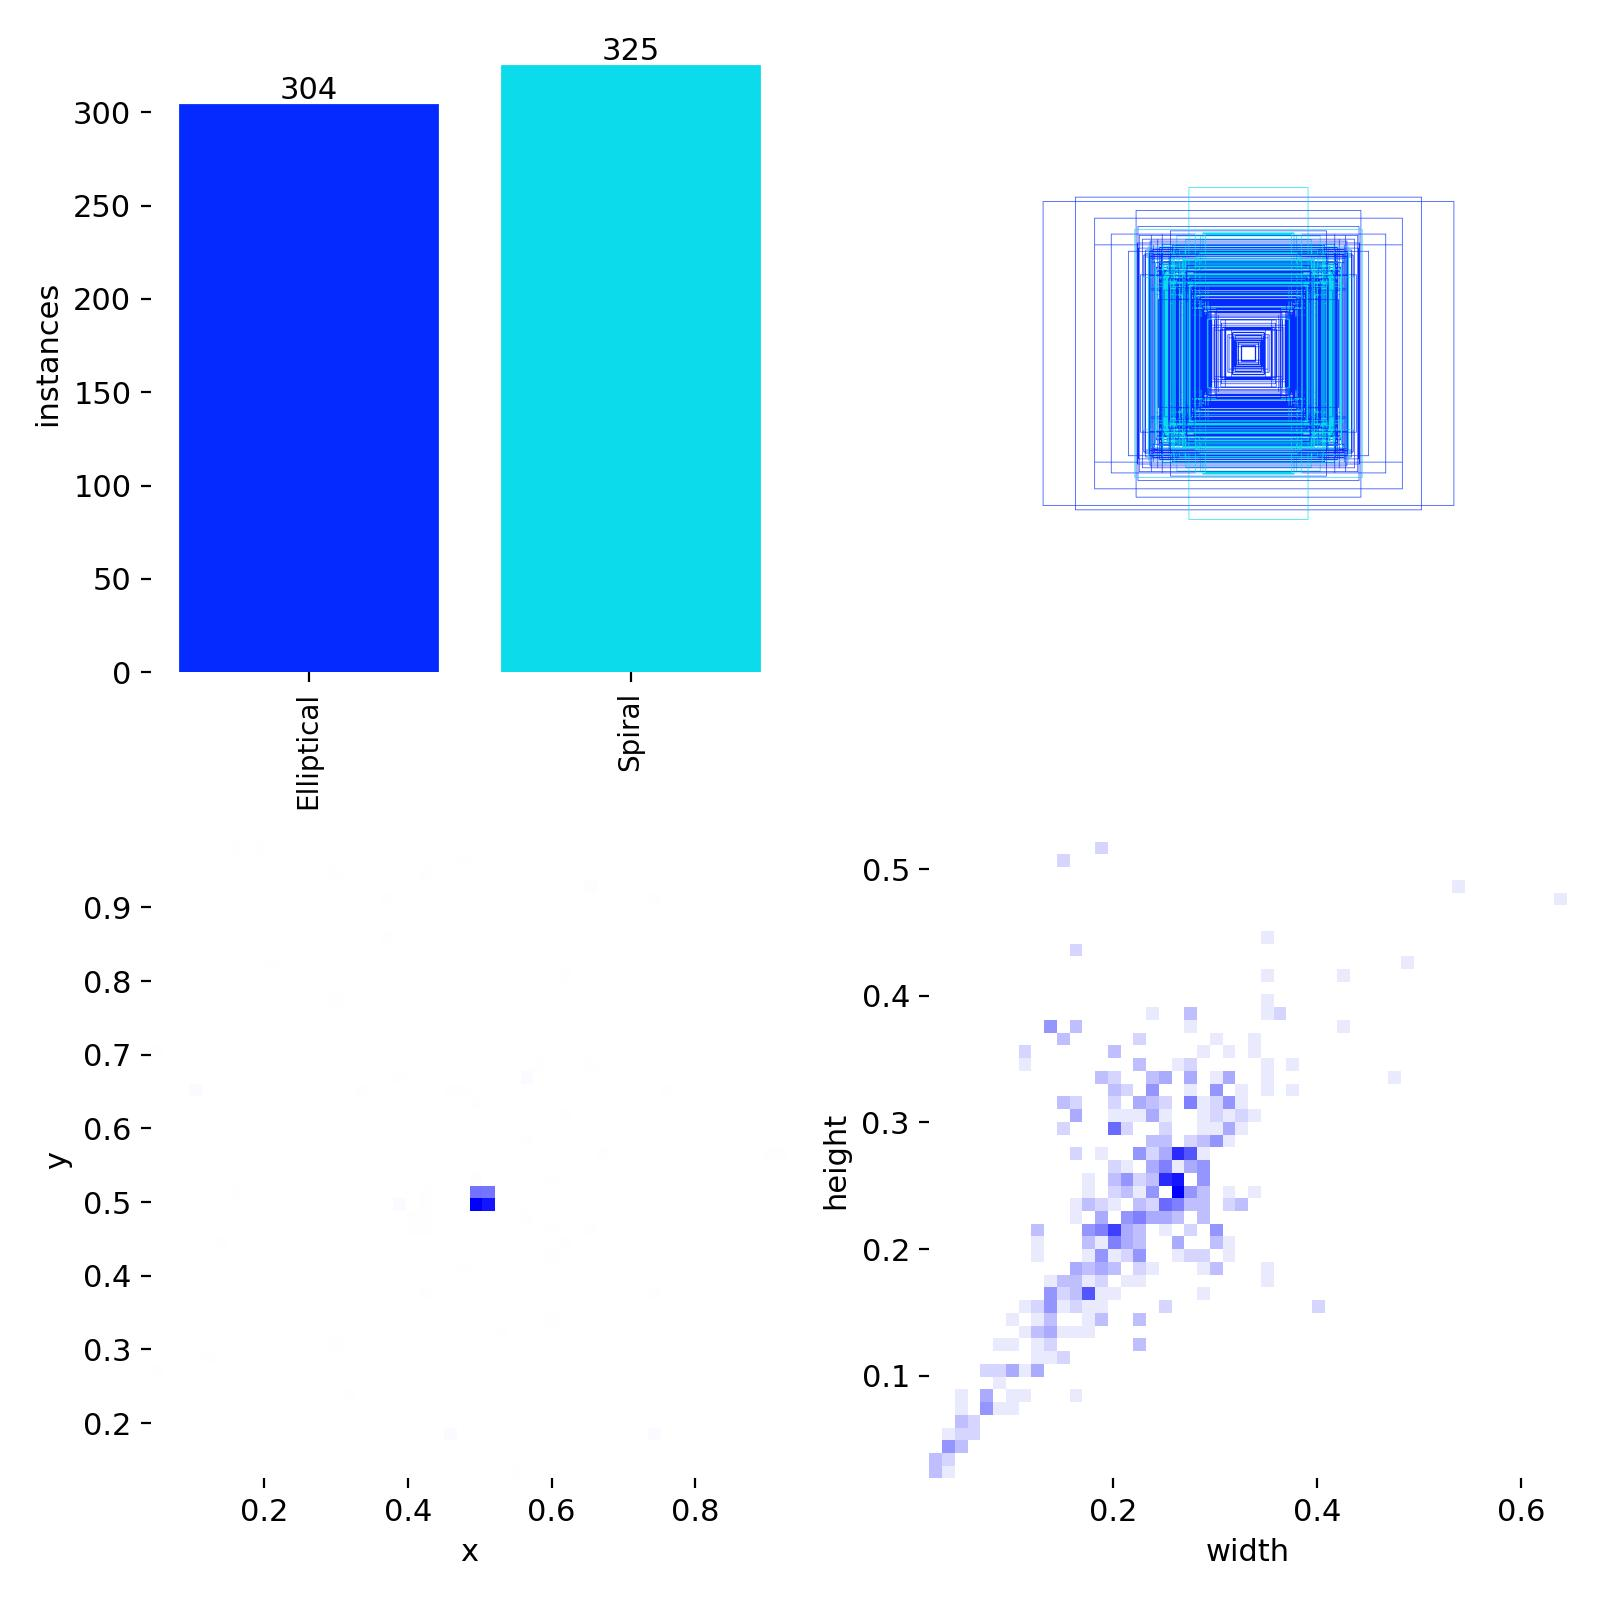


Target File: train_batch542.jpg


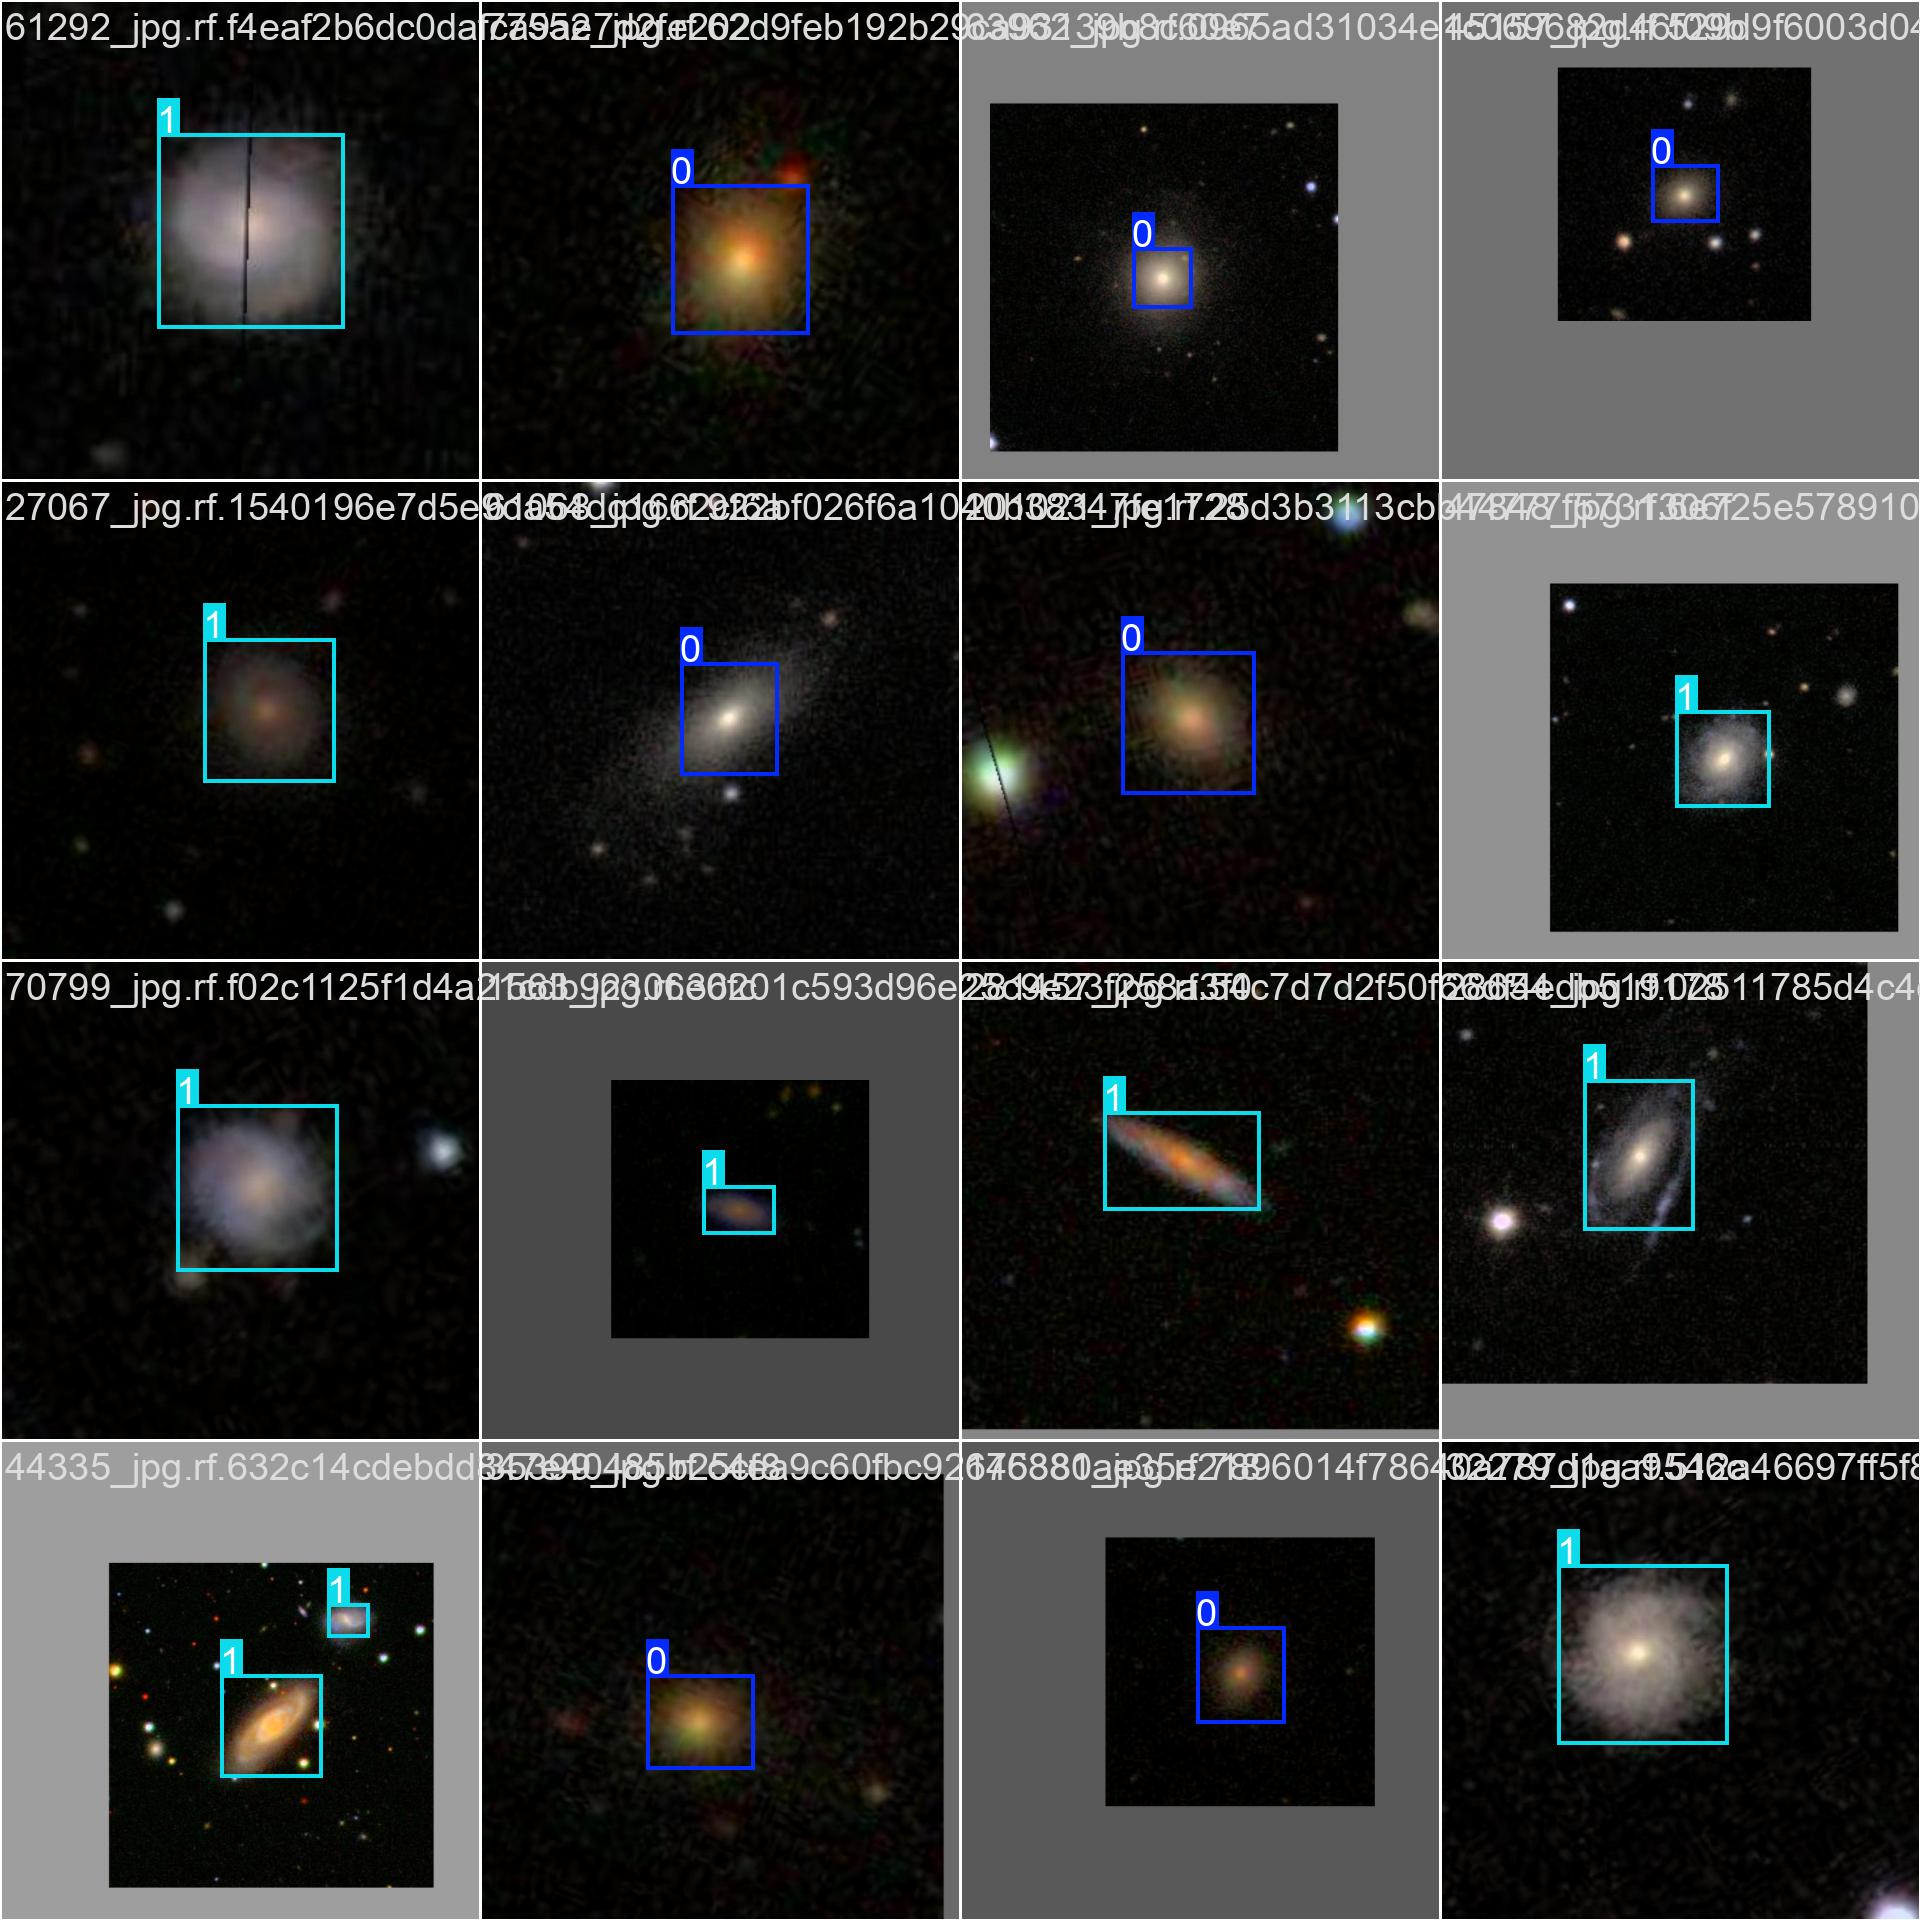


Target File: train_batch541.jpg


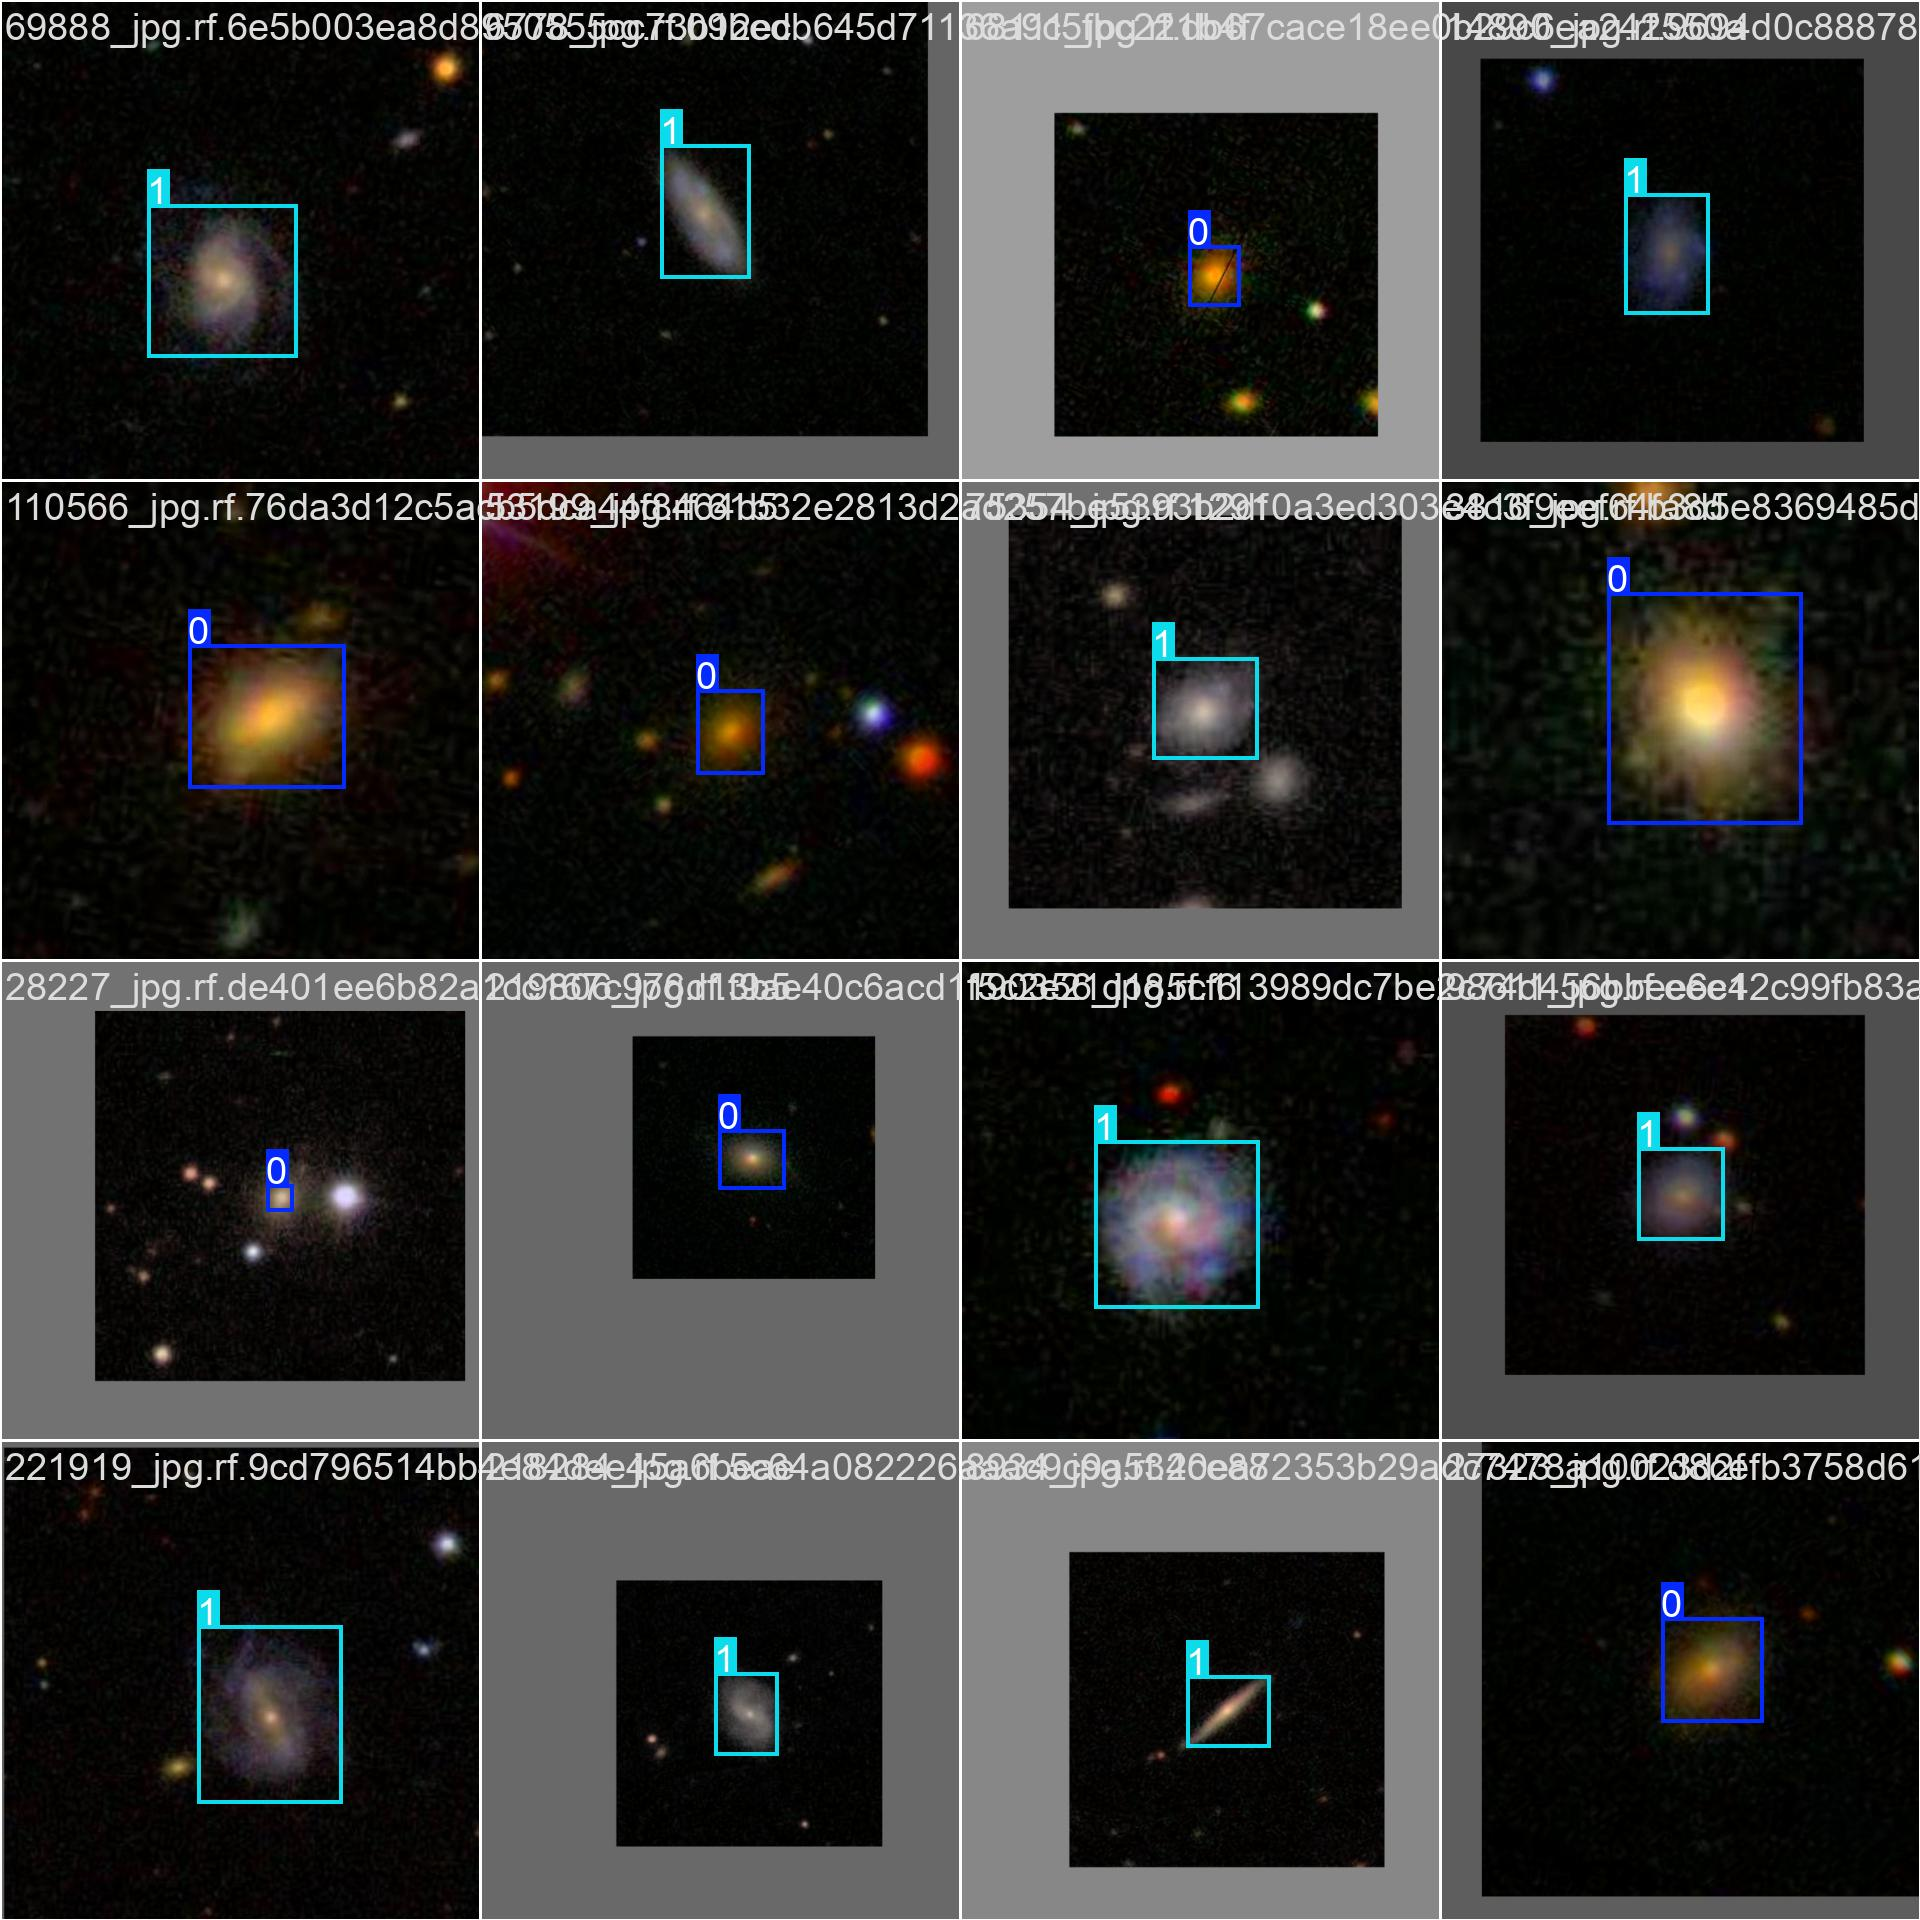

In [5]:
import glob
import os
from IPython.display import Image, display

# Isolate the most recent detection directory generated during training
latest_run_path = max(glob.glob('/content/runs/detect/*'), key=os.path.getmtime)
predicted_images = glob.glob(f"{latest_run_path}/*.jpg") + glob.glob(f"{latest_run_path}/*.png")

print(f"Rendering evaluation samples from: {latest_run_path}")

# Display up to 3 annotated target images
for img_path in predicted_images[:3]:
    print(f"\nTarget File: {os.path.basename(img_path)}")
    display(Image(filename=img_path, width=600))